# Dimensionality Reduction

So far in this course we have worked on **supervised** machine learning: we have a labeled data set,
and we try to learn a mapping between our features and our known labels. **Unsupervised** machine
learning is a different paradigm. Each sample still has features associated with it, but we have
**no labels at all**. What we are looking for instead are groupings, patterns, or simplifications
that we can find in the data using only the features themselves.

This page covers the first half of the unsupervised lecture:

- why we need to reduce the dimensionality of large data sets (the **curse of dimensionality**)
- the main families of **dimensionality reduction** methods
- **Principal Component Analysis (PCA)** — how it works, and how it is applied
- when PCA **doesn't** work well

Clustering — the other major branch of classical unsupervised learning — is covered in the
[Clustering](clustering.ipynb) notes. Later in the course we will also revisit unsupervised learning
from a deep learning perspective.

Once you have worked through these notes, the [Tutorial on Dimensionality
Reduction](PCA.ipynb) applies PCA hands-on to image data and to tropical Pacific sea surface
temperatures.


## The curse of dimensionality

The **curse of dimensionality** refers to the challenges that arise as the dimensionality of a data
set increases: increased sparsity, greater computational complexity, and decreased efficiency in
machine learning and data analysis tasks.

The intuition is a counting argument. Suppose each feature can take one of $n$ distinct values:

- with **1** feature, there are $n$ possible states a sample could occupy
- with **2** features, there are $n^2$
- with **3** features, there are $n^3$
- with $m$ features, there are $n^m$

Every dimension you add multiplies the number of places your data could live. But the number of
samples you actually have stays the same. So as dimensionality grows, your data set becomes
**very sparse**: training instances end up far away from one another, and there is a lot of empty
space between them. Two samples that each have only two features are likely to be reasonably close
to each other; two samples in very high dimensions are likely to be very far apart.

This matters because most machine learning relies on some notion of samples being "near" or
"similar to" one another. When every point is far from every other point, that notion breaks down,
and the risk of **overfitting** increases — the model can fit the sparse training points exactly
while learning nothing that generalizes.


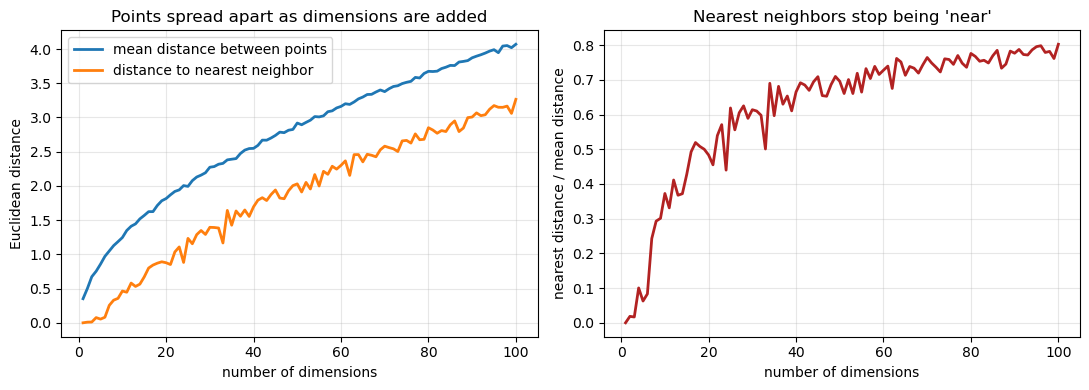

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# For a fixed number of samples, how far apart do random points become
# as we add dimensions? Points are drawn uniformly in the unit hypercube.
dims = np.arange(1, 101)
n_samples = 500
mean_dist, min_dist = [], []

for d in dims:
    P = rng.random((n_samples, d))
    # pairwise distances between a subset (keeps this fast)
    diff = P[:100, None, :] - P[None, :100, :]
    D = np.sqrt((diff ** 2).sum(-1))
    D = D[np.triu_indices(100, k=1)]
    mean_dist.append(D.mean())
    min_dist.append(D.min())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(dims, mean_dist, lw=2, label="mean distance between points")
ax1.plot(dims, min_dist, lw=2, label="distance to nearest neighbor")
ax1.set_xlabel("number of dimensions")
ax1.set_ylabel("Euclidean distance")
ax1.set_title("Points spread apart as dimensions are added")
ax1.legend()
ax1.grid(alpha=0.3)

# The ratio matters more than the absolute distance: when the nearest point is
# almost as far away as the average point, "nearest neighbor" stops meaning much.
ax2.plot(dims, np.array(min_dist) / np.array(mean_dist), lw=2, color="firebrick")
ax2.set_xlabel("number of dimensions")
ax2.set_ylabel("nearest distance / mean distance")
ax2.set_title("Nearest neighbors stop being 'near'")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The right-hand panel is the important one. In 1D, your nearest neighbor is essentially on
top of you while a typical point is far away, so "who is nearest?" is a very meaningful question. By
100 dimensions the nearest point is already about **three-quarters** as far as the average point, and
the ratio is still climbing toward 1 — everything is starting to look equidistant, and the number of
samples we would need to fill the space grows exponentially.

### Data usually lives on a lower-dimensional manifold

Here is the saving grace. Real data sets may have very many features, but the states those variables
*actually* take within the high-dimensional feature space are far fewer than every possible
combination. In practice, the **degrees of freedom are limited**.

Climate is a good example. A climate model has many, many variables and parameters — but only
certain parameter values are physically reasonable, and only certain climate states would ever be
expected to occur in the real world. So despite the enormous nominal dimensionality of the data
set, the number of real states it can occupy is far smaller.

Data that nominally lives in a high-dimensional space but really occupies a lower-dimensional
surface within it is said to live on a **manifold**. Unsupervised machine learning helps us discover,
and then exploit, these lower-dimensional relationships.


## Dimensionality reduction

**Dimensionality reduction** refers to techniques that reduce the number of features in a data set
while retaining the essential information. It is used for:

- **Data visualization** — we can only really look at 2 or 3 dimensions at a time
- **Data analysis** — finding interpretable patterns
- **Feature engineering** — reducing many variables to a smaller, more informative set before
  feeding them to a model
- **Improved model performance** — focusing only on the features that matter most for the problem,
  and reducing computational expense

The main families of methods are:

- **Projection methods** linearly transform data to lower dimensions. **Principal Component
  Analysis (PCA)** is by far the most common, and is the focus of these notes.
- **Manifold learning methods** capture the underlying data structure for *non-linear*
  relationships. Examples are **t-distributed Stochastic Neighbor Embedding (t-SNE)** and
  **Uniform Manifold Approximation and Projection (UMAP)**. These draw on ideas from topology and
  Riemannian manifolds that are beyond the scope of this course. They are used mostly for
  **visualizing** high-dimensional data in a lower-dimensional space, and less for quantitative
  analysis.
- **Deep learning methods** non-linearly transform data to lower dimensions. **Auto-encoders** and
  **variational auto-encoders** can be thought of as a non-linear generalization of PCA. We will
  return to these later in the course.


## Why do we need dimensionality reduction in climate and environmental science?

In this field we very often have **high-dimensional spatio-temporal data sets**. A climate model, a
weather model, or a hydrology model gives you data at every single point in space and time, for a
number of different variables. These are extremely high-dimensional data sets.

But what we are usually interested in is *not* the exact value of temperature or wind at every
single point in space and time. It is the **patterns** that emerge from these models and that tell
us something about how the real world works. Dimensionality reduction helps us to:

- **Make sense of high-dimensional data** — for example, Lee et al. (2023, *Journal of Climate*)
  applied unsupervised dimensionality reduction to weather data over North America, looking at the
  500 mb pressure level to find recurring patterns in jet stream behavior.
- **Discover inherent patterns and correlations** — Nakamura et al. (2009, *Journal of Climate*)
  looked at hurricanes and tropical cyclones in the Atlantic and found subsets of repeated cyclone
  track patterns that emerged naturally from historic storm data. Uncovering those patterns is a
  route to learning about the physical drivers behind them.
- **Feature engineering** and **reducing computational expense**.


## Principal Component Analysis (PCA)

The basic idea behind PCA is that we find a transformation of our features into a new coordinate
system, where the data is projected along the **directions of greatest variance**. The principal
components are ordered by how much variance they explain: the first principal component is the
direction of greatest variance in the data set, the second is the direction of the next greatest
variance (constrained to be orthogonal to the first), and so on.

When PCA is applied to spatio-temporal data, as it often is in climate and meteorology, it is also
known as **Empirical Orthogonal Function (EOF) analysis**. The two are effectively equivalent in
terms of the method used — the terminology just differs by field.


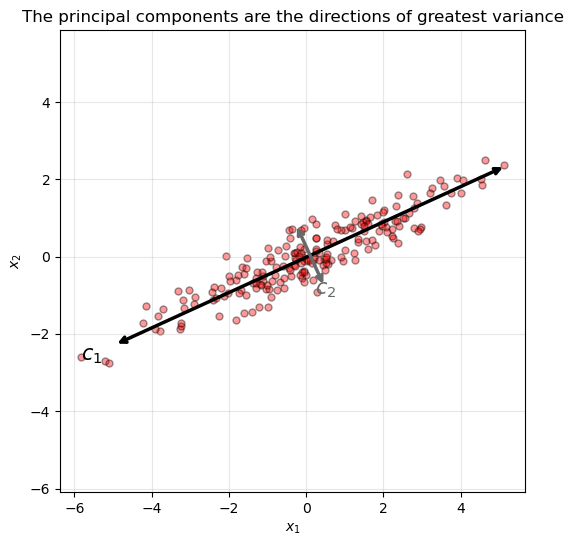

variance explained by each component: [0.975 0.025]


In [2]:
from sklearn.decomposition import PCA

# A simple 2D data set with a clear direction of greatest variance.
rng = np.random.default_rng(4)
n = 200
base = rng.normal(0, 1, n)
X = np.column_stack([base * 2.0 + rng.normal(0, 0.35, n),
                     base * 0.9 + rng.normal(0, 0.35, n)])

pca = PCA(n_components=2).fit(X)

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c="red", alpha=0.4, edgecolor="k", s=25)

# Draw each principal component, scaled by how much variance it explains.
mean = pca.mean_
colors = ["black", "dimgray"]
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    v = comp * np.sqrt(var) * 2.5
    plt.annotate("", mean + v, mean - v,
                 arrowprops=dict(arrowstyle="<->", lw=2.5, color=colors[i]))
    plt.text(*(mean + v * 1.12), f"$c_{i+1}$", fontsize=15, color=colors[i],
             ha="center", va="center")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("The principal components are the directions of greatest variance")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

print("variance explained by each component:", pca.explained_variance_ratio_.round(3))

$x_1$ and $x_2$ are the original variables. The direction of greatest variance in this data set
is along $c_1$ — that is the **first principal component**. The next direction of greatest variance
is $c_2$, the **second principal component**. If we transform our coordinates so that the data lies
along $c_1$ and $c_2$, we get a much simpler description of the data set, one that captures the
directions in which it actually varies.

Notice how lopsided the explained variance is here. Almost all the variability is along $c_1$, which
means we could describe this data set with a *single* number per sample and lose very little.


### How to proceed, step by step

Our data is in a data matrix $\mathbf{X}$ of shape $n_{samples} \times n_{features}$. Done by hand,
PCA works like this:

1. **Mean-center the data**, so it is centered on the origin:

   $$\mathbf{X}_c = \mathbf{X} - \mathbf{X}_{mean}$$

2. **Apply Singular Value Decomposition (SVD)**, a matrix factorization technique, to the centered
   matrix:

   $$\mathbf{X}_c = \mathbf{U}\,\mathbf{\Sigma}\,\mathbf{V}^{T}$$

   The matrix $\mathbf{V}$ contains all of the principal components — the rows of $\mathbf{V}^T$ are
   the principal directions, ordered from most to least variance explained.

3. **Choose the number of dimensions** $d$ you want to keep, to retain as much variance as you need.

4. **Project** the data onto the first $d$ principal directions. With numpy's
   `U, s, Vt = np.linalg.svd(X_centered)`, that is `X_centered @ Vt[:d].T`, which gives an
   $n_{samples} \times d$ matrix — one row per sample, one column per component kept.

   (Watch the transposes here. `Vt[:d]` picks the first $d$ principal directions as *rows*, so it
   needs transposing back to $n_{features} \times d$ before the multiply. Equivalently, you are
   multiplying by the first $d$ *columns* of $\mathbf{V}$.)

In practice you would use `scikit-learn`'s `PCA`, which has already implemented this matrix
factorization for you, and which follows the usual scikit-learn pattern: initialize with the number
of components you want, then `fit_transform` on your feature matrix.


In [3]:
# Doing it by hand with SVD...
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
print("principal directions from SVD:")
print(Vt[:2])

# ...gives the same answer as scikit-learn.
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)
print("\nprincipal directions from scikit-learn:")
print(pca.components_)

principal directions from SVD:
[[ 0.90947526  0.41575804]
 [-0.41575804  0.90947526]]

principal directions from scikit-learn:
[[-0.90947526 -0.41575804]
 [ 0.41575804 -0.90947526]]


The two agree (up to an overall sign — a principal direction and its negative describe the
same axis, so the sign PCA hands back is arbitrary).


### How many dimensions should we keep?

Once we have the principal components, we project the data onto them. If we keep only the
**leading** principal components and their amplitudes, we can use that smaller subset of variables
to effectively **compress** the data while still keeping the majority of the variance in the
original data set.

To decide how many to keep, we look at the **cumulative explained variance** against the number of
dimensions retained, and pick the point where we have as much of the original variance as we need
(95% is a common choice).


original shape: (1797, 64)


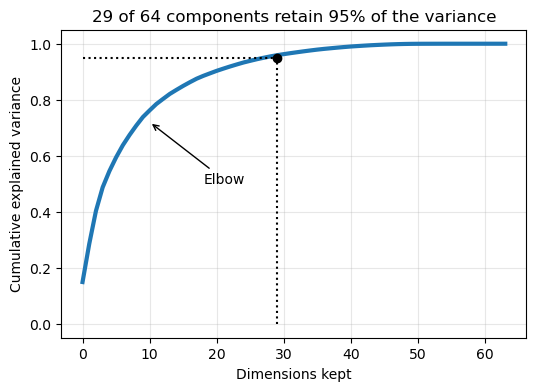

29 components retain 95.5% of the variance (down from 64 features)


In [4]:
from sklearn.datasets import load_digits

# Handwritten digit images, 8x8 pixels flattened into 64 features per sample.
digits = load_digits()
Xd = digits.data
print("original shape:", Xd.shape)

pca_full = PCA().fit(Xd)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

plt.figure(figsize=(6, 4))
plt.plot(cumsum, lw=3)
plt.xlabel("Dimensions kept")
plt.ylabel("Cumulative explained variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(10, 0.72), xytext=(18, 0.5),
             arrowprops=dict(arrowstyle="->"))
plt.title(f"{d} of {Xd.shape[1]} components retain 95% of the variance")
plt.grid(alpha=0.3)
plt.show()

print(f"{d} components retain {cumsum[d-1]*100:.1f}% of the variance "
      f"(down from {Xd.shape[1]} features)")

The curve rises steeply and then bends — the **elbow** — after which each extra dimension buys
very little additional variance.

The same argument scales up. In the [tutorial](PCA.ipynb) you will apply PCA to the MNIST data set,
where each image has **784** features. There, retaining about 95% of the original variance takes
only slightly more than **150** dimensions rather than the original 784. That is a powerful result:
we get substantial dimensionality reduction and compression while keeping the most important
information in the data.


### PCA can transform variables to separate different classes

If what we care about is telling classes apart, PCA can find a transformation into a space where
the classes are more easily separable.

The classic demonstration is the **Iris** data set bundled with scikit-learn: three species of iris,
each described by four features.


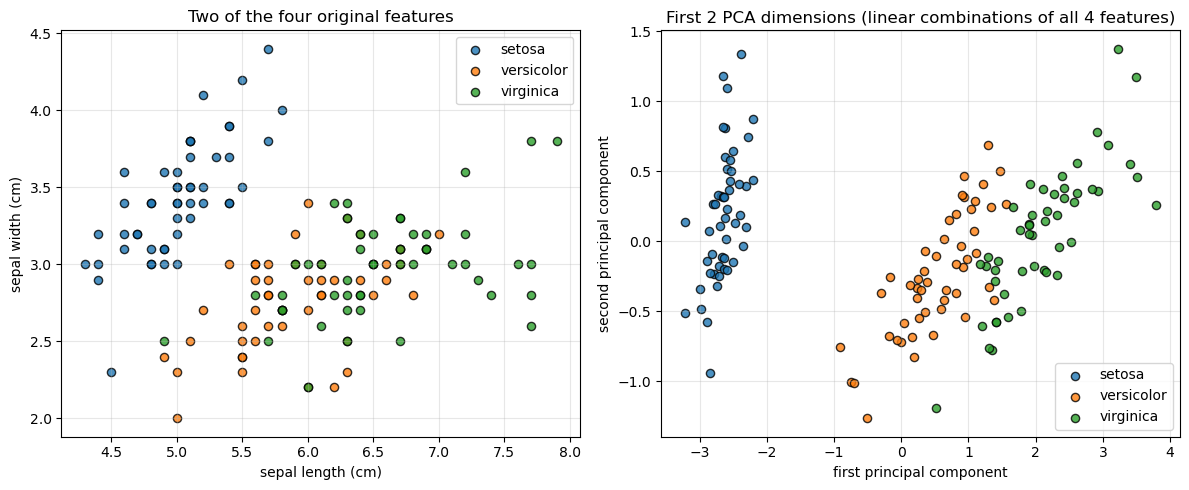

In [5]:
from sklearn.datasets import load_iris

iris = load_iris()
Xi, yi = iris.data, iris.target

# The four original features, plotted two at a time.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k, name in enumerate(iris.target_names):
    axes[0].scatter(Xi[yi == k, 0], Xi[yi == k, 1], label=name,
                    edgecolor="k", s=35, alpha=0.8)
axes[0].set_xlabel(iris.feature_names[0])
axes[0].set_ylabel(iris.feature_names[1])
axes[0].set_title("Two of the four original features")
axes[0].legend()
axes[0].grid(alpha=0.3)

# The same data, projected onto its first two principal components.
Xi_pca = PCA(n_components=2).fit_transform(Xi)
for k, name in enumerate(iris.target_names):
    axes[1].scatter(Xi_pca[yi == k, 0], Xi_pca[yi == k, 1], label=name,
                    edgecolor="k", s=35, alpha=0.8)
axes[1].set_xlabel("first principal component")
axes[1].set_ylabel("second principal component")
axes[1].set_title("First 2 PCA dimensions (linear combinations of all 4 features)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In the space of the original features (left), two of the three classes overlap and are hard to
separate. After PCA (right), we have new variables that are **linear combinations of the four
original features**, and the classes are considerably easier to separate — you could plausibly draw
decision boundaries between them.

This is why dimensionality reduction is often used **in combination with** the clustering methods in
the [next set of notes](clustering.ipynb): together they let us do **unsupervised classification**,
where we don't start with labeled data, but instead find a transformation into a space where the
classes within our data set separate out on their own.


## When does PCA not work well?

PCA has trouble with:

- **Non-linear relationships** — high-dimensional data oriented on a complex manifold
- **Outliers**

Be careful with the first one: *high dimensionality on its own is not the problem*. We just used PCA
to take 64-dimensional digits down to 29, and in the tutorial it takes MNIST from 784 down to 154.
What defeats PCA is high-dimensional data whose structure is **curved**. PCA can only rotate and
project, so if the information lives on a bent surface, no flat projection will recover it.

**Outliers** are a separate weakness, and follow directly from what PCA optimizes. It picks the
directions of greatest *variance*, and a far-away point contributes a very large squared distance —
so a handful of outliers can drag a principal axis toward themselves and away from the structure of
the bulk of the data.

The standard illustration of the non-linear case is the **Swiss roll**. It is a 3D data set, but the
data is really rolled up on what would be two dimensions if we could find a transformation that
flattened it out. PCA — being a *linear* transformation — cannot do that. It can only project, so it
squashes the roll flat and smears together points that are far apart along the roll.

Manifold learning methods do a much better job with this kind of structure.


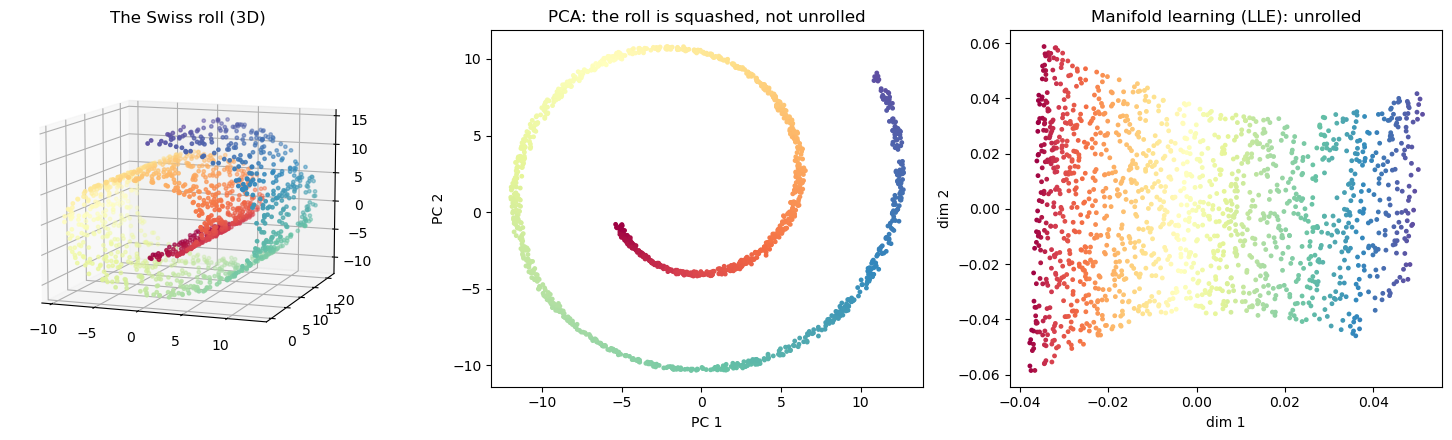

In [6]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_sr, color = make_swiss_roll(n_samples=1500, noise=0.05, random_state=42)

fig = plt.figure(figsize=(15, 4.5))

ax = fig.add_subplot(131, projection="3d")
ax.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=color, cmap="Spectral", s=6)
ax.set_title("The Swiss roll (3D)")
ax.view_init(10, -70)

# PCA: a linear projection. It cannot unroll anything.
ax = fig.add_subplot(132)
X_pca = PCA(n_components=2).fit_transform(X_sr)
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap="Spectral", s=6)
ax.set_title("PCA: the roll is squashed, not unrolled")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

# Manifold learning: recovers the 2D surface the data actually lives on.
ax = fig.add_subplot(133)
X_lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10,
                               random_state=42).fit_transform(X_sr)
ax.scatter(X_lle[:, 0], X_lle[:, 1], c=color, cmap="Spectral", s=6)
ax.set_title("Manifold learning (LLE): unrolled")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")

plt.tight_layout()
plt.show()

The color encodes position *along* the roll. In the PCA panel the colors fold back over each
other — points from opposite ends of the roll land on top of one another, because a flat projection
of a curled sheet necessarily overlaps. In the manifold learning panel the color varies smoothly
from one side to the other: the 2D structure has been recovered.

None of this makes PCA a bad method. It remains extremely useful precisely **because** it is a linear
transformation: it is fast, and it is fairly easy to interpret, which is why it is so widely used.
It is just worth knowing what it can and cannot see.

There are many other dimensionality reduction methods available; it is worth reading the
[scikit-learn documentation](https://scikit-learn.org/stable/modules/manifold.html) and exploring,
depending on the data set you are working with.

## Where next

The [Tutorial on Dimensionality Reduction](PCA.ipynb) puts PCA to work on real data — compressing
handwritten digit images, and then applying EOF analysis to tropical Pacific sea surface
temperatures to recover the El Niño/Southern Oscillation pattern without ever labeling it.

The [Clustering](clustering.ipynb) notes cover the other half of classical unsupervised learning.
